In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor


from sklearn.model_selection import cross_val_score

In [53]:
x = pd.read_csv(r"../data/selected/selcetd_train_x.csv")
y=pd.read_csv(r"../data/selected/train_y.csv")

x = x.drop(columns="Unnamed: 0")
y =y.drop(columns="Unnamed: 0")

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [55]:
x_train
y_train =y_train.squeeze()
y_test=y_test.squeeze()

In [56]:
x = x_train.copy()
y=y_train.copy()
xt=x_test.copy()
yt=y_test.copy()

In [57]:
x=x.drop(columns=['RemodelAge',"HouseAge","GarageType_Detchd","Foundation_PConc","MasVnrType_None"])

xt=xt.drop(columns=['RemodelAge',"HouseAge","GarageType_Detchd","Foundation_PConc","MasVnrType_None"])

In [58]:
preformact_dict ={}

In [59]:
#linear tree regression

LRM = LinearRegression()

LRM.fit(x_train,y_train)

predicted = LRM.predict(x_test)



In [60]:
comparison_df = pd.concat(
    [
        y_test.reset_index(drop=True),
        pd.DataFrame(predicted, columns=["Predicted"])
    ],
    axis=1
)

#rsquraed
r2 = r2_score(y_test,comparison_df["Predicted"])
mae = mean_absolute_error(y_test,comparison_df["Predicted"])
mse= mean_squared_error(y_test,comparison_df["Predicted"])
rmse = np.sqrt(mse)
n=x_test.shape[0]
k=x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
        adjusted_re :{adjusted_r2}
""")

c_score = cross_val_score(
    LRM,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

c_score.mean()

r2 : 0.8537733687915492
        mae : 20859.714235233423
        mse : 1020383142.9188632
        rmse : 31943.43661722801
        adjusted_re :0.8382252206630557



np.float64(0.7750841215374218)

In [61]:
preformact_dict["linear_regression"] = [ 0.85377,20859.71,1020383142,31943.43]
                                        #r2  0    #mae  1    #mse 2   #rmse 3

In [62]:
#decision tree

DTR = DecisionTreeRegressor(random_state=42)

DTR.fit(x_train,y_train)

y_predict = DTR.predict(x_test)

In [63]:
comparison_df_dtr= pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(y_predict, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_dtr["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_dtr["Predicted"])
mse= mean_squared_error(y_test,comparison_df_dtr["Predicted"])
n=x_test.shape[0]
k=x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
rmse = np.sqrt(mse)
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
        adjusted_re :{adjusted_r2}
""")

c_score = cross_val_score(
    DTR,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)

c_score.mean()




r2 : 0.811791625191952
        mae : 25017.931506849316
        mse : 1313335686.0045662
        rmse : 36239.97359276861
        adjusted_re :0.7917795954655267



np.float64(0.6459044225274161)

In [64]:
preformact_dict["decision_tree"] = [0.81179,25017.93,1313335686,36239.97]

In [65]:
#random forest

RDG = RandomForestRegressor(random_state=42)

RDG.fit(x_train,y_train)

RDG_Predict = RDG.predict(x_test)

In [66]:
comparison_df_RDG = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(RDG_Predict, columns=["Predicted"])],axis=1)

comparison_df_RDG

r2 = r2_score(y_test,comparison_df_RDG["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_RDG["Predicted"])
mse= mean_squared_error(y_test,comparison_df_RDG["Predicted"])
rmse = np.sqrt(mse)
n=x_test.shape[0]
k=x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"""r2 : {r2}
    mae : {mae}
    mse : {mse}
    rmse : {rmse}
    adjusted_r2 : {adjusted_r2}
        
""")

cv = cross_val_score(
    RDG,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("avg r2 : ",cv.mean())



r2 : 0.9001814179683261
    mae : 16993.145410958907
    mse : 696543424.5010324
    rmse : 26392.10913324345
    adjusted_r2 : 0.889567796587743


avg r2 :  0.8120856303643796


In [67]:
preformact_dict["random_forest"] = [0.90018,16993.14,696543424,26392]

In [68]:
#gradient boost regressor

GRB = GradientBoostingRegressor(random_state=42,learning_rate=0.1,max_depth=3,n_estimators=100,subsample=1.0,)

GRB.fit(x, y_train)

y_pred = GRB.predict(xt)

In [69]:
comparison_df_GRB = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(y_pred, columns=["Predicted"])],axis=1)

comparison_df_GRB

,SalePrice,Predicted
0,154500,141931.530042
1,325000,348758.814257
2,115000,127104.088535
3,159000,146498.007851
4,315500,319942.822244
...,...,...
433,139000,129744.942613
434,126175,124252.100887
435,205950,194403.805522
436,110000,135188.849633


In [70]:
r2 = r2_score(y_test,comparison_df_GRB["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_GRB["Predicted"])
mse= mean_squared_error(y_test,comparison_df_GRB["Predicted"])
rmse = np.sqrt(mse)
n=xt.shape[0]
k=xt.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"""r2 : {r2}
    mae : {mae}
    mse : {mse}
    rmse : {rmse}
    adjusted_r2 : {adjusted_r2}
        
""")

cv = cross_val_score(
    GRB,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("avg r2 : ",cv.mean())


r2 : 0.9080235776445127
    mae : 16983.670026456777
    mse : 641820098.9923444
    rmse : 25334.168606692907
    adjusted_r2 : 0.8995157585766301


avg r2 :  0.8034950504115311


In [71]:
preformact_dict["gradient_boost"] = [0.90802,16983.67,641820098,25334.16]

In [72]:
#xgb regressor
xgb_op  = xgb.XGBRegressor(random_state=42,max_depth=7,n_estimators=300,subsample =0.8)
xgb_op.fit(x_train, y_train)
y_pred = xgb_op.predict(x_test)


In [73]:
comparison_df_xgb = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(y_pred, columns=["Predicted"])],axis=1)

comparison_df_xgb

r2 = r2_score(y_test,comparison_df_xgb["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_xgb["Predicted"])
mse= mean_squared_error(y_test,comparison_df_xgb["Predicted"])
rmse = np.sqrt(mse)
n=x_test.shape[0]
k=x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"""r2 : {r2}
    mae : {mae}
    mse : {mse}
    rmse : {rmse}
    adjusted_r2 : {adjusted_r2}
        
""")

cv = cross_val_score(
    GRB,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("avg r2 : ",cv.mean())

r2 : 0.8820847272872925
    mae : 19029.90625
    mse : 822823808.0
    rmse : 28684.90557767273
    adjusted_r2 : 0.8695469008216374


avg r2 :  0.8034950504115311


In [74]:
preformact_dict["Xgb"] = [0.8820,19029.90,822823808,28684.90]

In [75]:
#lgbm regressor

In [76]:
LGB = lgb.LGBMRegressor(random_state=42,learning_rate=0.05,max_depth=None,n_estimators=100,num_leaves=50)

LGB.fit(x, y_train)

y_pred = LGB.predict(xt)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2622
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 37
[LightGBM] [Info] Start training from score 181312.692759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [77]:
comparison_df_lgbr = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(y_pred, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_lgbr["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_lgbr["Predicted"])
mse= mean_squared_error(y_test,comparison_df_lgbr["Predicted"])
rmse = np.sqrt(mse)
n=x.shape[0]
k=xt.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
        adjusted_r2 : {adjusted_r2}
""")

cv = cross_val_score(
    LGB,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()

r2 : 0.8809118730523475
        mae : 17305.112760962646
        mse : 831008115.6553615
        rmse : 28827.211374938117
        adjusted_r2 : 0.876433965839885

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000602 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2646
[LightGBM] [Info] Number of data points in the train set: 817, number of used features: 42
[LightGBM] [Info] Start training from score 179744.681763
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

np.float64(0.8375612430233362)

In [78]:
preformact_dict["lgbm"] = [0.88091,17305.11,831008115,28827.21]

In [79]:
#catboost regressor
CBR = CatBoostRegressor(random_state=42)

CBR.fit(x_train,y_train)

cbr_predict = CBR.predict(x_test)

Learning rate set to 0.041084
0:	learn: 75597.8604469	total: 2.62ms	remaining: 2.62s
1:	learn: 73709.3172597	total: 4.57ms	remaining: 2.28s
2:	learn: 71930.0775930	total: 6.04ms	remaining: 2.01s
3:	learn: 70149.5127890	total: 7.62ms	remaining: 1.9s
4:	learn: 68464.4320860	total: 9.21ms	remaining: 1.83s
5:	learn: 66890.3597452	total: 11ms	remaining: 1.83s
6:	learn: 65433.4329022	total: 13ms	remaining: 1.84s
7:	learn: 63833.3493247	total: 15.2ms	remaining: 1.89s
8:	learn: 62311.7990001	total: 17.3ms	remaining: 1.9s
9:	learn: 61044.5991176	total: 19.5ms	remaining: 1.93s
10:	learn: 59702.7459005	total: 21.6ms	remaining: 1.94s
11:	learn: 58452.4458067	total: 23.4ms	remaining: 1.92s
12:	learn: 57177.3070281	total: 24.9ms	remaining: 1.89s
13:	learn: 56004.6654464	total: 28.4ms	remaining: 2s
14:	learn: 54837.0885878	total: 32.9ms	remaining: 2.16s
15:	learn: 53769.3928072	total: 37.2ms	remaining: 2.29s
16:	learn: 52727.5291729	total: 39.7ms	remaining: 2.29s
17:	learn: 51651.7243967	total: 43.6m

In [80]:
comparison_df_cbr = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(cbr_predict, columns=["Predicted"])],axis=1)

r2 = r2_score(y_test,comparison_df_cbr["Predicted"])
mae = mean_absolute_error(y_test,comparison_df_cbr["Predicted"])
mse= mean_squared_error(y_test,comparison_df_cbr["Predicted"])
rmse = np.sqrt(mse)
n=x.shape[0]
k=xt.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"""r2 : {r2}
        mae : {mae}
        mse : {mse}
        rmse : {rmse}
        adjusted_r2 :{adjusted_r2}
""")

cv = cross_val_score(
    CBR,
    x_train,
    y_train,
    cv=5,
    scoring="r2"
)
cv.mean()

r2 : 0.9130134976837346
        mae : 16350.610993694267
        mse : 606999969.0990636
        rmse : 24637.36936239467
        adjusted_r2 :0.9097426637551759

Learning rate set to 0.039656
0:	learn: 74373.6928490	total: 1.69ms	remaining: 1.69s
1:	learn: 72625.5412317	total: 3.84ms	remaining: 1.92s
2:	learn: 71083.4354793	total: 5.7ms	remaining: 1.89s
3:	learn: 69424.0544667	total: 7.71ms	remaining: 1.92s
4:	learn: 67712.3436330	total: 9.71ms	remaining: 1.93s
5:	learn: 66164.9371737	total: 11.4ms	remaining: 1.89s
6:	learn: 64829.9439443	total: 13.8ms	remaining: 1.96s
7:	learn: 63363.5381937	total: 16.3ms	remaining: 2.02s
8:	learn: 61944.5493720	total: 18.2ms	remaining: 2.01s
9:	learn: 60576.5487352	total: 20.2ms	remaining: 2s
10:	learn: 59281.2819007	total: 23.1ms	remaining: 2.08s
11:	learn: 58029.2591729	total: 26ms	remaining: 2.14s
12:	learn: 56808.2305023	total: 28ms	remaining: 2.13s
13:	learn: 55616.5007331	total: 29.9ms	remaining: 2.11s
14:	learn: 54515.6849035	total: 31.8ms	re

np.float64(0.8362111729452202)

In [81]:
preformact_dict['catboost'] = [0.91301,16350.61,606999969,24637.36]

In [82]:
comparison_df_cbr

,SalePrice,Predicted
0,154500,145279.133267
1,325000,349666.838134
2,115000,107675.841786
3,159000,143302.153388
4,315500,344330.258648
...,...,...
433,139000,134958.467936
434,126175,122390.574865
435,205950,202275.435504
436,110000,140110.307740


In [83]:
# from above all 7 model catboost regressor perform well where it have high r2 score and less mse rmse val compared to others

In [84]:
importance = CBR.get_feature_importance()

importance

array([ 1.61251616,  4.90874839, 16.20725981,  3.45919278,  2.2814886 ,
        0.80113972,  1.11453887,  2.45955569,  1.89443902,  1.80050047,
        2.3870046 ,  0.32337856,  4.9907964 ,  1.48186894,  7.40361006,
        0.7537065 ,  1.34186799,  1.34171906,  1.80042915,  2.53979205,
        2.04677726,  2.25937848,  2.70137395,  1.75577143,  2.47847519,
        0.17883692,  0.02125676,  0.09922963,  0.40962371,  0.212165  ,
        0.1740544 ,  0.05442003,  0.04665361,  0.96706173,  0.18152852,
        0.34828249,  0.53679508,  2.79827847,  1.87067373, 11.3709383 ,
        4.01333064,  4.57154185])

In [85]:
import_feature = pd.DataFrame({
    "col_nmae" : x_train.columns, 
    "val" :importance
})
import_feature = import_feature.sort_values(by="val",ascending=False)

import_feature=import_feature.reset_index(drop=True)


import_feature = import_feature.iloc[0:10,0:]

import_feature

filtered_df_train = x_train[["OverallQual","TotalSf","GrLivArea","1stFlrSF","LotArea","TotalLivArea","TotalBathrooms","YearBuilt","HouseAge","GarageArea"]]
filtered_df_test =x_test[["OverallQual","TotalSf","GrLivArea","1stFlrSF","LotArea","TotalLivArea","TotalBathrooms","YearBuilt","HouseAge","GarageArea"]]

In [86]:
import_feature

,col_nmae,val
0,OverallQual,16.207260
1,TotalSf,11.370938
2,GrLivArea,7.403610
3,1stFlrSF,4.990796
4,LotArea,4.908748
5,TotalLivArea,4.571542
6,TotalBathrooms,4.013331
7,YearBuilt,3.459193
8,HouseAge,2.798278
9,GarageArea,2.701374


In [87]:
filtered_df_train

,OverallQual,TotalSf,GrLivArea,1stFlrSF,LotArea,TotalLivArea,TotalBathrooms,YearBuilt,HouseAge,GarageArea
135,7,1311.428333,7.428333,7.428333,9.249657,1311.428333,2.0,1970,38,530
1452,5,553.978214,6.978214,6.978214,8.209580,553.978214,2.0,2005,1,525
762,7,1545.639876,7.344719,6.639876,9.064274,763.344719,2.5,2009,1,614
932,9,1912.552762,7.552762,7.552762,9.364862,1912.552762,2.0,2006,1,788
435,7,1639.719013,7.415777,6.719013,9.275004,806.415777,3.5,1996,13,550
...,...,...,...,...,...,...,...,...,...,...
1095,6,1321.181592,7.181592,7.181592,9.139703,1321.181592,2.0,2006,1,440
1130,4,1782.192182,7.591862,7.192182,8.962520,1129.591862,3.0,1928,81,576
1294,5,870.762730,6.762730,6.762730,9.008591,870.762730,2.0,1955,51,572
860,7,1432.816736,7.263330,6.816736,8.941545,919.263330,1.5,1918,89,216


In [88]:
CBR = CatBoostRegressor(random_state=42)

CBR.fit(filtered_df_train,y_train)

predicted=CBR.predict(filtered_df_test)

Learning rate set to 0.041084
0:	learn: 75529.6723112	total: 2.41ms	remaining: 2.4s
1:	learn: 73671.0498840	total: 5.08ms	remaining: 2.53s
2:	learn: 71863.5219429	total: 7.88ms	remaining: 2.62s
3:	learn: 70151.7935498	total: 9.97ms	remaining: 2.48s
4:	learn: 68330.6205581	total: 11.4ms	remaining: 2.26s
5:	learn: 66536.3506956	total: 13.5ms	remaining: 2.23s
6:	learn: 64782.6510565	total: 15.1ms	remaining: 2.13s
7:	learn: 63185.3821551	total: 16.3ms	remaining: 2.02s
8:	learn: 61659.0259213	total: 17.8ms	remaining: 1.96s
9:	learn: 60228.3834375	total: 19.3ms	remaining: 1.91s
10:	learn: 58976.3152924	total: 21ms	remaining: 1.89s
11:	learn: 57592.6485826	total: 23.4ms	remaining: 1.92s
12:	learn: 56250.9928305	total: 25ms	remaining: 1.9s
13:	learn: 55043.7402614	total: 26.6ms	remaining: 1.88s
14:	learn: 53925.1699535	total: 28.4ms	remaining: 1.87s
15:	learn: 52892.2052346	total: 30ms	remaining: 1.84s
16:	learn: 51814.0137694	total: 31.8ms	remaining: 1.84s
17:	learn: 50768.4226409	total: 33.4

In [89]:
r2_score(y_test,predicted)

0.9062701713687207

In [90]:
comparison_df = pd.concat([
        y_test.reset_index(drop=True),
        pd.DataFrame(predicted, columns=["Predicted"])],axis=1)



In [91]:
comparison_df

,SalePrice,Predicted
0,154500,139432.747705
1,325000,349111.671505
2,115000,113380.974711
3,159000,139098.181356
4,315500,317112.425971
...,...,...
433,139000,133109.206750
434,126175,110988.537940
435,205950,204009.726346
436,110000,127003.830005


In [92]:
joblib.dump(CBR, "model.pkl")

['model.pkl']

In [93]:
filtered_df_test

,OverallQual,TotalSf,GrLivArea,1stFlrSF,LotArea,TotalLivArea,TotalBathrooms,YearBuilt,HouseAge,GarageArea
892,6,1065.974479,6.974479,6.974479,9.037771,1065.974479,1.5,1963,43,264
1105,8,2592.313887,7.872074,7.313887,9.413852,1470.872074,3.5,1994,16,712
413,5,1014.936343,6.936343,6.936343,9.100637,1014.936343,1.0,1927,83,360
522,6,1670.912743,7.417580,6.912743,8.517393,1011.417580,2.0,1947,59,420
1036,9,1627.390799,7.390799,7.390799,9.464905,1627.390799,3.0,2007,2,912
...,...,...,...,...,...,...,...,...,...,...
331,5,1062.963190,6.963190,6.963190,9.009081,1062.963190,2.0,1958,49,308
323,3,1169.059618,7.059618,7.059618,8.669227,1169.059618,2.0,1955,51,220
650,7,1662.712956,7.418181,6.712956,9.002824,820.418181,2.5,2007,1,562
439,6,1202.529419,7.087574,6.529419,9.421816,691.087574,1.0,1920,89,528


In [94]:
filtered_df_train.to_csv(r"../data/predict_feature/featured_columns.csv",index=False)
filtered_df_test.to_csv(r"../data/predict_feature/featured_test_columns.csv",index=False)


In [95]:
preformact_dict

{'linear_regression': [0.85377, 20859.71, 1020383142, 31943.43],
 'decision_tree': [0.81179, 25017.93, 1313335686, 36239.97],
 'random_forest': [0.90018, 16993.14, 696543424, 26392],
 'gradient_boost': [0.90802, 16983.67, 641820098, 25334.16],
 'Xgb': [0.882, 19029.9, 822823808, 28684.9],
 'lgbm': [0.88091, 17305.11, 831008115, 28827.21],
 'catboost': [0.91301, 16350.61, 606999969, 24637.36]}

In [96]:
performance_compraison = pd.DataFrame(preformact_dict,index=["r2","mae","mse","rmse"])
performance_compraison

,linear_regression,decision_tree,random_forest,gradient_boost,Xgb,lgbm,catboost
r2,8.537700e-01,8.117900e-01,9.001800e-01,9.080200e-01,8.820000e-01,8.809100e-01,9.130100e-01
mae,2.085971e+04,2.501793e+04,1.699314e+04,1.698367e+04,1.902990e+04,1.730511e+04,1.635061e+04
mse,1.020383e+09,1.313336e+09,6.965434e+08,6.418201e+08,8.228238e+08,8.310081e+08,6.070000e+08
rmse,3.194343e+04,3.623997e+04,2.639200e+04,2.533416e+04,2.868490e+04,2.882721e+04,2.463736e+04


In [97]:
performance_compraison.to_csv(r"../data/predict_feature/performance.csv",index=True)

In [98]:
#actual vs predicted plot

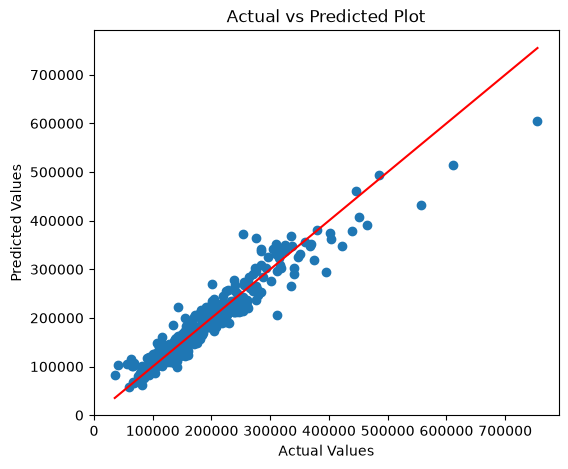

In [99]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, cbr_predict)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Plot')
plt.savefig("../static/images/act-vs-prd.png", dpi=300, bbox_inches="tight")
plt.show()


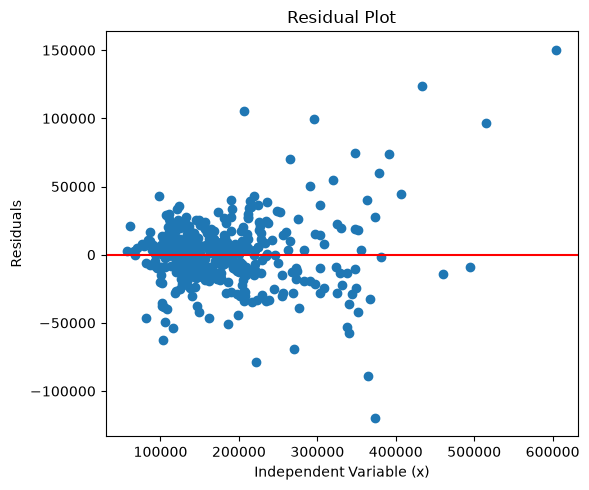

In [100]:
#residual plot
plt.figure(figsize=(6,5))
residual = y_test - cbr_predict
x=0
# Plot
plt.scatter(cbr_predict,residual)
plt.axhline(y=0,color = "red") # Zero line
plt.title("Residual Plot")
plt.xlabel("Independent Variable (x)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("../static/images/residual.png", dpi=300, bbox_inches="tight")
plt.show()


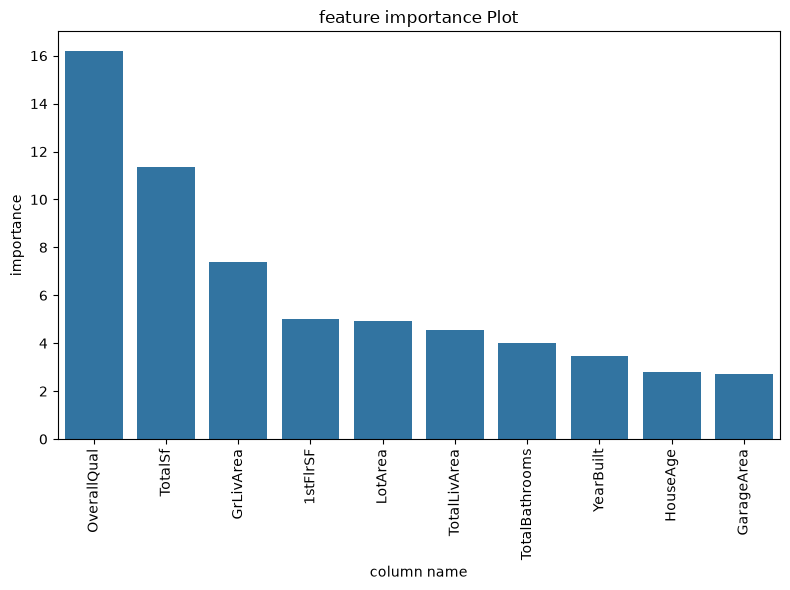

In [101]:
#feature importance

plt.figure(figsize=(8,6))
sns.barplot(data=import_feature,x="col_nmae",y="val")
plt.title("feature importance Plot")
plt.xlabel("column name")
plt.ylabel("importance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../static/images/feature-importance.png", dpi=300, bbox_inches="tight")
plt.show()

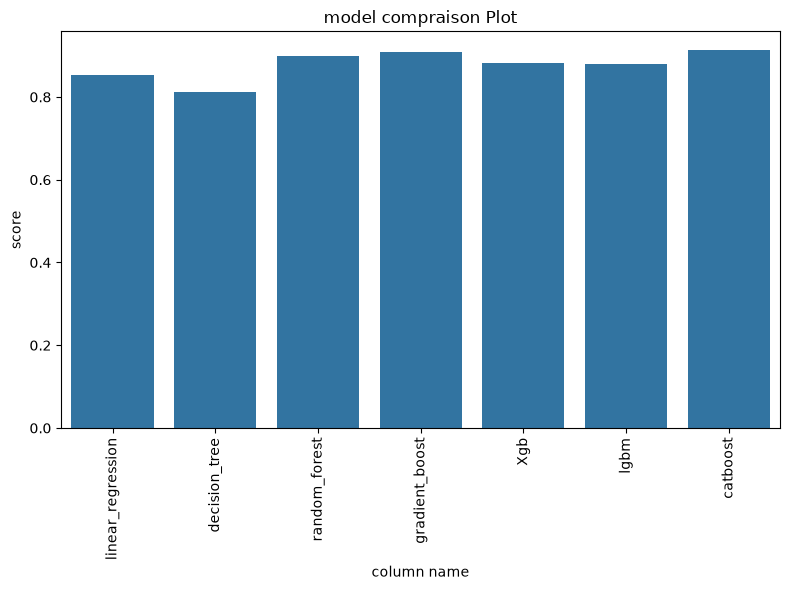

In [102]:
plt.figure(figsize=(8,6))

ax=sns.barplot(x=performance_compraison.columns,y=performance_compraison.iloc[0])


plt.title("model compraison Plot")
plt.xlabel("column name")
plt.ylabel("score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../static/images/model_comparaison.png", dpi=300, bbox_inches="tight")
plt.show()